# Early Stopping and Regularization

**Unit:** Unit 4: Neural Networks Fundamentals

**Why this notebook?** A big neural network can get a *perfect* score on its
training data and still be bad at its actual job. On small, noisy datasets the
network stops learning the real pattern and starts memorizing the noise — this
is **overfitting**, and it is the single most common failure mode you will hit
when training neural networks. In this notebook we overfit a network *on
purpose*, learn to spot the damage in the training curves, and then compare
three standard fixes — early stopping, dropout, and L2 weight regularization —
on exactly the same data so the numbers are directly comparable.

## 📚 Learning Objectives

By completing this notebook, you will:
- Diagnose overfitting from train-vs-validation curves
- Stop training at the right moment with the `EarlyStopping` callback
- Reduce memorization with `Dropout` layers
- Penalize large weights with L2 regularization
- Compare all three fixes in one summary table and pick a winner

## 🔗 Where this fits

**Builds on:** Unit 4, lesson 04 "Multi-class Classification with Keras" — the training curves read there are where overfitting shows up first; every fix below changes the loss or when you stop descending it (Unit 3, lesson 04).

**Used later in:** Course 04 (AIAT 114) — Unit 2, which formalises this as the bias-variance tradeoff.

---


## 🎯 2,212 papers, 62 models, none usable

In March 2021 *Nature Machine Intelligence* published Roberts et al., a systematic
review of machine-learning models built to detect or prognosticate COVID-19 from
chest radiographs and CT scans. They screened **2,212 studies**, kept **62** after
quality filtering, and reached one conclusion: **none of the models was of
potential clinical use**, because of methodological flaws and biases in the
underlying data.

This was not a shortage of talent or of accuracy figures. The published papers
were full of excellent scores. What they lacked, repeatedly, was any reason to
believe the score would survive contact with a different hospital: models trained
and tested on the same small, non-representative collections; duplicated images
across the train and test split; and datasets assembled so that "COVID-positive"
and "the hospital that supplied the image" were the same variable, letting a
network learn the source instead of the disease.

Every one of those is a version of what you are about to produce **on purpose**
below: a model that scores brilliantly on the data it was shown and worse on
anything else. The reason this notebook overfits deliberately is that overfitting
does not announce itself. It looks like success.

### What goes wrong without a validation curve

You watch training accuracy climb, you feel good, and you ship. In the baseline
run below, validation loss reaches its best value at **epoch 7** and then more
than doubles by epoch 150, while training accuracy keeps climbing to 0.943. Every
epoch after the seventh made the model *better at the 300 passengers it had seen
and worse at its actual job* — and the only instrument that reveals it is a score
on data the model was not trained on.


## The Experiment Plan

We teach this comparatively — one baseline, then change **one thing at a time**:

1. **Baseline:** train a deliberately *too-big* MLP on a small noisy dataset and watch it overfit.
2. **Fix 1 — Early stopping:** same model, but stop training when validation loss stops improving.
3. **Fix 2 — Dropout:** same model, but randomly drop 30% of hidden activations during training.
4. **Fix 3 — L2:** same model, but penalize large weights in the loss function.

**The dataset:** the real 1912 Titanic passenger manifest that ships with this
diploma. We take a random **600-passenger** sample (300 train / 300 validation)
described by ten columns built from class, sex, age, family size, fare and port
of embarkation, and predict who survived.

Real data supplies the noise for us, and it is not the kind you can dial in.
Two passengers with identical tickets, ages and cabins-classes did not always
share a fate: who reached a lifeboat depended on where they were standing, who
they were with, and luck. So a large part of the label is genuinely
unpredictable from these ten columns — which is exactly the situation where
overfitting bites hardest. Any model pushed to 100% training accuracy on 300
passengers has memorized individual people, not learned a pattern.

In [1]:
# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root and put it on sys.path, then import the shared loader.
# WHY:  a hard-coded '../../../Course 04/datasets/raw/titanic.csv' only resolves when the
#       kernel's working directory happens to be this notebook's folder. This does not care.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/"
            "AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load        # load("titanic"), load("montgomery_911_calls"), ...
# -------------------------------------------------------------------------------------

In [2]:
# Real data that overfits easily: a small sample of the Titanic manifest. Small
# (600 passengers), and irreducibly noisy — survival is only partly explained by the
# columns a 1912 clerk wrote down. Perfect conditions for a big net to memorize.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split

print("=== Dataset: the real Titanic manifest, deliberately kept small ===")
titanic = load("titanic")
print(f"Full manifest: {len(titanic)} passengers")
print(f"Missing values per column that we use:")
print(titanic[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]]
      .isna().sum().to_string())

# Real gaps need a real decision: fill missing ages with the median age and missing
# ports with the most common port, rather than throwing 177 passengers away.
df = titanic.copy()
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Ten numeric columns: class, sex, age, siblings/spouses, parents/children, fare,
# family size, "travelling alone" flag, and one-hot columns for two of the three ports.
features = pd.DataFrame({
    "pclass": df["Pclass"],
    "is_female": (df["Sex"] == "female").astype(int),
    "age": df["Age"],
    "sibsp": df["SibSp"],
    "parch": df["Parch"],
    "fare": df["Fare"],
    "family_size": df["SibSp"] + df["Parch"] + 1,
    "is_alone": ((df["SibSp"] + df["Parch"]) == 0).astype(int),
})
features = pd.concat([features, pd.get_dummies(df["Embarked"], prefix="port",
                                               drop_first=True).astype(int)], axis=1)
labels = df["Survived"].to_numpy()

# Standardize so no column dominates the gradient, then take a 600-passenger sample.
X_all = ((features - features.mean()) / features.std()).to_numpy(dtype="float32")
rng = np.random.default_rng(7)          # sampling is randomness we CHOOSE, not fake data
idx = rng.choice(len(X_all), size=600, replace=False)
X, y = X_all[idx], labels[idx]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.5, stratify=y, random_state=7
)

print(f"\nFeature columns: {list(features.columns)}")
print(f"Training set:   {X_train.shape[0]} passengers x {X_train.shape[1]} features")
print(f"Validation set: {X_val.shape[0]} passengers x {X_val.shape[1]} features")
print(f"Class balance (train): {np.bincount(y_train)} (died, survived)")
print(f"Always-predict-'died' baseline on validation: {(y_val == 0).mean():.3f}")

=== Dataset: the real Titanic manifest, deliberately kept small ===
titanic: full file, 891 rows.
Full manifest: 891 passengers
Missing values per column that we use:
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2

Feature columns: ['pclass', 'is_female', 'age', 'sibsp', 'parch', 'fare', 'family_size', 'is_alone', 'port_Q', 'port_S']
Training set:   300 passengers x 10 features
Validation set: 300 passengers x 10 features
Class balance (train): [189 111] (died, survived)
Always-predict-'died' baseline on validation: 0.630


## Step 1 — Deliberately Overfit a Too-Big MLP

**What:** an MLP with hidden layers of 256 → 256 → 128 units — over **100,000
trainable parameters** — trained on just **300 rows** for 150 epochs.

**Why this is asking for trouble:** with hundreds of parameters *per training
sample*, the network has more than enough capacity to memorize every passenger
individually — including the many whose fate these ten columns cannot explain.

**How we detect the damage:** we track loss and accuracy on the *validation*
set after every epoch. Memorization drives training loss to ~0 while validation
loss gets *worse* — that widening gap is the signature of overfitting.

All four experiments below share the same `build_model` / `train_and_eval`
helpers, the same random seed, and the same 150-epoch budget, so any difference
in the results comes from the single change we make each time.

In [3]:
# The baseline experiment: an oversized MLP (~100k parameters for 300 real passengers)
# trained 150 epochs with no regularization — watch validation loss get WORSE while
# train loss falls. That divergence is memorization, and it is easy to produce.
EPOCHS = 150
HIDDEN = [256, 256, 128]

def build_model(dropout=0.0, l2_lambda=0.0):
    """Same architecture every time; dropout / L2 are the only knobs."""
    keras.utils.set_random_seed(42)   # identical init for every experiment
    layers = [Input(shape=(X_train.shape[1],))]
    for units in HIDDEN:
        reg = l2(l2_lambda) if l2_lambda > 0 else None
        layers.append(Dense(units, activation="relu", kernel_regularizer=reg))
        if dropout > 0:
            layers.append(Dropout(dropout))
    layers.append(Dense(1, activation="sigmoid"))
    model = Sequential(layers)
    model.compile(optimizer="adam", loss="binary_crossentropy",
                  metrics=["accuracy"])
    return model

# Shared bookkeeping: every experiment below records its metrics here for the final summary table.
results = {}   # name -> dict of final metrics
histories = {} # name -> keras History

def train_and_eval(name, model, callbacks=None):
    history = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                        epochs=EPOCHS, batch_size=32, verbose=0,
                        callbacks=callbacks or [])
    tr_loss, tr_acc = model.evaluate(X_train, y_train, verbose=0)
    va_loss, va_acc = model.evaluate(X_val, y_val, verbose=0)
    results[name] = {"train_acc": tr_acc, "val_acc": va_acc,
                     "gap": tr_acc - va_acc, "val_loss": va_loss,
                     "epochs_run": len(history.history["loss"])}
    histories[name] = history
    print(f"{name}:")
    print(f"  epochs run          : {len(history.history['loss'])}")
    print(f"  final train accuracy: {tr_acc:.3f}")
    print(f"  final val accuracy  : {va_acc:.3f}   (gap: {tr_acc - va_acc:+.3f})")
    print(f"  final val loss      : {va_loss:.3f}")
    return history

print("=== Baseline: too-big MLP, no regularization ===")
baseline = build_model()
print(f"Trainable parameters: {baseline.count_params():,} "
      f"(~{baseline.count_params() // X_train.shape[0]} per training sample!)\n")
h_base = train_and_eval("Baseline (no regularization)", baseline)

best_ep = int(np.argmin(h_base.history["val_loss"])) + 1
print(f"\nVal loss was best at epoch {best_ep} "
      f"({min(h_base.history['val_loss']):.3f}) and then got WORSE "
      f"({h_base.history['val_loss'][-1]:.3f} by epoch {EPOCHS}).")

=== Baseline: too-big MLP, no regularization ===
Trainable parameters: 101,633 (~338 per training sample!)



Baseline (no regularization):
  epochs run          : 150
  final train accuracy: 0.943
  final val accuracy  : 0.790   (gap: +0.153)
  final val loss      : 1.066

Val loss was best at epoch 7 (0.398) and then got WORSE (1.066 by epoch 150).


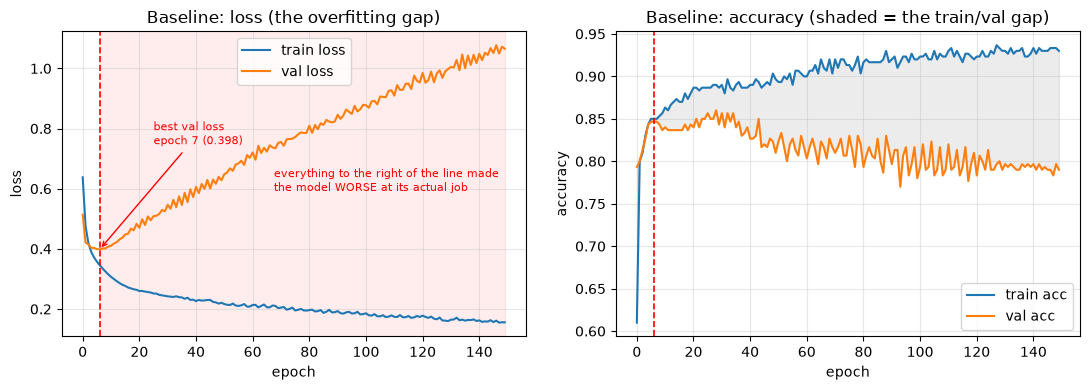

In [4]:
# The overfitting picture: train loss keeps falling, validation loss turns upward —
# the vertical gap between the curves IS the memorization.
# Plot the train-vs-validation curves for the baseline
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(h_base.history["loss"], label="train loss")
axes[0].plot(h_base.history["val_loss"], label="val loss")
# Mark the moment the model was at its best, and shade everything after it:
# WHY: those epochs are not "more training", they are damage you paid for.
axes[0].axvline(best_ep - 1, color="red", ls="--", lw=1.2)
axes[0].axvspan(best_ep - 1, EPOCHS - 1, color="red", alpha=0.07)
axes[0].annotate(f"best val loss\nepoch {best_ep} ({min(h_base.history['val_loss']):.3f})",
                 (best_ep - 1, min(h_base.history["val_loss"])),
                 xytext=(best_ep + 18, min(h_base.history["val_loss"]) + 0.35),
                 fontsize=8, color="red",
                 arrowprops=dict(arrowstyle="->", color="red", lw=1))
axes[0].text(EPOCHS * 0.45, max(h_base.history["val_loss"]) * 0.55,
             "everything to the right of the line made\nthe model WORSE at its actual job",
             fontsize=8, color="red")
axes[0].set_title("Baseline: loss (the overfitting gap)")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(h_base.history["accuracy"], label="train acc")
axes[1].plot(h_base.history["val_accuracy"], label="val acc")
axes[1].axvline(best_ep - 1, color="red", ls="--", lw=1.2)
axes[1].fill_between(range(EPOCHS), h_base.history["accuracy"],
                     h_base.history["val_accuracy"], color="gray", alpha=0.15)
axes[1].set_title("Baseline: accuracy (shaded = the train/val gap)")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy"); axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Reading the Curves

The plots above are the classic overfitting picture:

- **Training** loss keeps falling and training accuracy climbs to **0.943** — the
  network is memorizing individual passengers out of the 300 it was shown,
  including the many whose survival these ten columns cannot explain.
- **Validation** loss improves only for the first few epochs (best at
  **epoch 7**, loss **0.398**), then trends upward for the rest of training. By
  epoch 150 it has more than doubled (0.398 → **1.066**).
- Validation accuracy ends at **0.790** while training accuracy is 0.943 —
  that **train-vs-val gap of +0.153** is the damage. (For scale: predicting
  "died" for every passenger already scores 0.630 on this validation set.)

**In the figure itself:** the red dashed line is epoch 7, and everything shaded pink to its
right is 143 epochs of training that made the model *worse* at its actual job while looking
like progress on the blue curve. In the right panel, the grey band between the two accuracy
curves is that same damage measured in accuracy — watch it open from nothing at epoch 7 to
+0.153 at epoch 150.

Key insight: the model was at its *best* very early. Every epoch after that
made it better at the 300 passengers it had seen and worse at its real job. Now
let's fix it — one technique at a time, everything else identical.

## Fix 1 — Early Stopping

**What:** stop training when validation loss stops improving, instead of
running the full 150 epochs.

**Why:** the baseline curves showed the best model existed around epoch 7 —
after that, training only added memorization. Early stopping simply *quits
while we're ahead*.

**How:** Keras's `EarlyStopping` callback watches `val_loss`; if it hasn't
improved for `patience=15` epochs, training stops and
`restore_best_weights=True` rewinds the model to its best epoch.

In [5]:
# Fix 1 — early stopping: watch validation loss and stop when it stops improving,
# then restore the best weights. Regularization by simply not training too long.
print("=== Fix 1: EarlyStopping callback ===")
early_stop = EarlyStopping(monitor="val_loss", patience=15,
                           restore_best_weights=True)
h_es = train_and_eval("Early stopping", build_model(), callbacks=[early_stop])

base = results["Baseline (no regularization)"]
es = results["Early stopping"]
print(f"\nCompare: stopped after {es['epochs_run']} epochs instead of {EPOCHS},")
print(f"and val accuracy moved {base['val_acc']:.3f} -> {es['val_acc']:.3f} "
      f"({es['val_acc'] - base['val_acc']:+.3f}).")

=== Fix 1: EarlyStopping callback ===


Early stopping:
  epochs run          : 22
  final train accuracy: 0.850
  final val accuracy  : 0.847   (gap: +0.003)
  final val loss      : 0.398

Compare: stopped after 22 epochs instead of 150,
and val accuracy moved 0.790 -> 0.847 (+0.057).


## Fix 2 — Dropout

**What:** during training, each `Dropout(0.3)` layer randomly zeroes 30% of
the activations coming out of the hidden layer below it (dropout is switched
off automatically at evaluation time).

**Why:** if a unit can vanish at any moment, the network cannot rely on any
single unit to memorize a specific training row — it is pushed toward
redundant, more general features.

**How:** same architecture and 150-epoch budget as the baseline; the *only*
change is a `Dropout(0.3)` after each hidden layer.

In [6]:
# Fix 2 — dropout: randomly silence 30% of neurons each step so no neuron can rely
# on specific partners, forcing redundant, more general features.
print("=== Fix 2: Dropout(0.3) after each hidden layer ===")
h_do = train_and_eval("Dropout 0.3", build_model(dropout=0.3))

do = results["Dropout 0.3"]
print(f"\nCompare: val accuracy {base['val_acc']:.3f} -> {do['val_acc']:.3f} "
      f"({do['val_acc'] - base['val_acc']:+.3f}) with the same 150 epochs.")

=== Fix 2: Dropout(0.3) after each hidden layer ===


Dropout 0.3:
  epochs run          : 150
  final train accuracy: 0.897
  final val accuracy  : 0.813   (gap: +0.083)
  final val loss      : 0.648

Compare: val accuracy 0.790 -> 0.813 (+0.023) with the same 150 epochs.


## Fix 3 — L2 Weight Regularization

**What:** add a penalty `l2_lambda * sum(weights**2)` to the loss for every
hidden layer (`l2_lambda = 0.05` here).

**Why:** memorizing noisy labels typically needs large, very specific weights.
Punishing weight magnitude makes memorization *expensive*, so the optimizer
prefers smaller, smoother solutions that generalize better.

**How:** same architecture and budget; the only change is
`kernel_regularizer=l2(0.05)` on each hidden `Dense` layer. The strength
`l2_lambda` is a knob you have to tune: 0.05 is strong enough to close the
train-vs-val gap almost completely on 300 passengers, which is what makes the
mechanism easy to see here. **Try it:** re-run this cell with `l2_lambda=0.01`
and compare both the gap and the validation accuracy — a weaker penalty is not
automatically a worse model.

In [7]:
# Fix 3 — L2 weight decay: add a penalty on large weights to the loss, making pure
# memorization expensive; the model keeps only patterns worth their weight.
print("=== Fix 3: L2 weight regularization (lambda = 0.05) ===")
h_l2 = train_and_eval("L2 (lambda=0.05)", build_model(l2_lambda=0.05))

l2r = results["L2 (lambda=0.05)"]
print(f"\nCompare: val accuracy {base['val_acc']:.3f} -> {l2r['val_acc']:.3f} "
      f"({l2r['val_acc'] - base['val_acc']:+.3f}), and the train/val gap shrank from "
      f"{base['gap']:+.3f} to {l2r['gap']:+.3f}")
print(f"while train accuracy fell {base['train_acc']:.3f} -> {l2r['train_acc']:.3f} — "
      f"the penalty made memorization too expensive.")

=== Fix 3: L2 weight regularization (lambda = 0.05) ===


L2 (lambda=0.05):
  epochs run          : 150
  final train accuracy: 0.813
  final val accuracy  : 0.817   (gap: -0.003)
  final val loss      : 0.496

Compare: val accuracy 0.790 -> 0.817 (+0.027), and the train/val gap shrank from +0.153 to -0.003
while train accuracy fell 0.943 -> 0.813 — the penalty made memorization too expensive.


## Side-by-Side Comparison

Same data, same architecture, same seed, same epoch budget — one summary
table, plus the validation-loss curves of all four runs on one plot.

=== Summary: validation accuracy per approach ===
                              epochs_run  train_acc  val_acc    gap  val_loss
Baseline (no regularization)         150      0.943    0.790  0.153     1.066
Early stopping                        22      0.850    0.847  0.003     0.398
Dropout 0.3                          150      0.897    0.813  0.083     0.648
L2 (lambda=0.05)                     150      0.813    0.817 -0.003     0.496


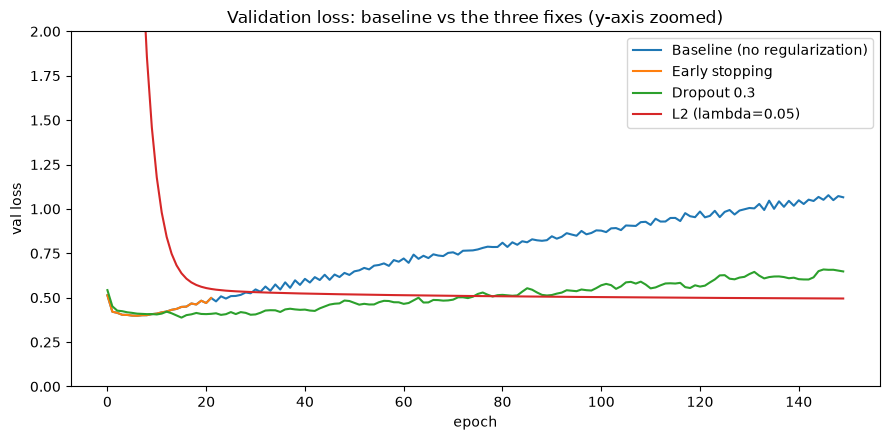

Note: the L2 curve's reported loss includes the weight penalty itself;
it falls below 2.0 by epoch 9, settles around epoch 20, and then stays
inside a narrow band (0.50-0.53) for the rest of training.


In [8]:
# Grand comparison: all four runs in one table and one plot — check which fix closed
# the train/validation gap most, and at what cost in epochs or train accuracy.
print("=== Summary: validation accuracy per approach ===")
summary = pd.DataFrame(results).T
summary = summary[["epochs_run", "train_acc", "val_acc", "gap", "val_loss"]]
summary["epochs_run"] = summary["epochs_run"].astype(int)
print(summary.round(3).to_string())

fig, ax = plt.subplots(figsize=(9, 4.5))
for name, h in histories.items():
    ax.plot(h.history["val_loss"], label=name)
# Note: Keras reports loss INCLUDING the L2 weight penalty, so the L2 curve
# starts near 18 (huge penalty at random init) — we zoom in to compare shapes.
ax.set_ylim(0, 2.0)
ax.set_title("Validation loss: baseline vs the three fixes (y-axis zoomed)")
ax.set_xlabel("epoch"); ax.set_ylabel("val loss")
ax.legend()
plt.tight_layout()
plt.show()
print("Note: the L2 curve's reported loss includes the weight penalty itself;")
print("it falls below 2.0 by epoch 9, settles around epoch 20, and then stays")
print("inside a narrow band (0.50-0.53) for the rest of training.")

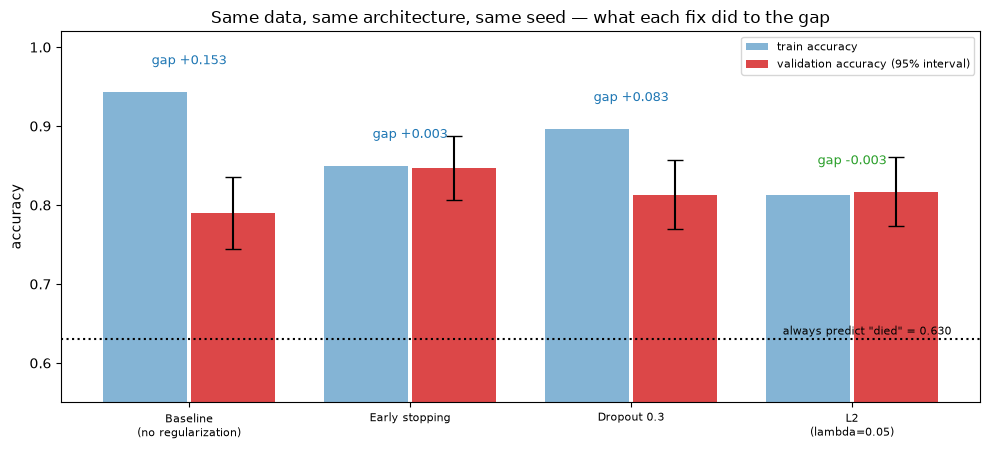

run                            |  train |    val |     gap | epochs
------------------------------------------------------------------
Baseline (no regularization)   |  0.943 |  0.790 |  +0.153 |    150
Early stopping                 |  0.850 |  0.847 |  +0.003 |     22
Dropout 0.3                    |  0.897 |  0.813 |  +0.083 |    150
L2 (lambda=0.05)               |  0.813 |  0.817 |  -0.003 |    150

Best validation accuracy: Early stopping (0.847)
95% interval half-width on 300 validation passengers: ±0.041 (±12 passengers)
Spread between the three fixes: 0.033 — smaller than that interval.


In [9]:
# WHAT/WHY: the table above is the result of the whole notebook, and a table hides
# the two things that matter: how far apart the four runs really are, and how much of
# that distance a 300-passenger validation set can actually resolve.
names = list(results)
train_accs = [results[n]["train_acc"] for n in names]
val_accs = [results[n]["val_acc"] for n in names]
# 95% interval for an accuracy measured on n validation rows: 1.96*sqrt(p(1-p)/n)
n_val = len(y_val)
val_err = [1.96 * np.sqrt(a * (1 - a) / n_val) for a in val_accs]
baseline_rate = (y_val == 0).mean()

x = np.arange(len(names))
fig, ax = plt.subplots(figsize=(10, 4.6))
ax.bar(x - 0.2, train_accs, width=0.38, label="train accuracy", color="tab:blue", alpha=0.55)
ax.bar(x + 0.2, val_accs, width=0.38, yerr=val_err, capsize=6,
       label="validation accuracy (95% interval)", color="tab:red", alpha=0.85)
ax.axhline(baseline_rate, ls=":", color="black")
ax.text(len(names) - 0.55, baseline_rate + 0.006,
        f'always predict "died" = {baseline_rate:.3f}', fontsize=8, ha="right")
for xi, (tr, va) in enumerate(zip(train_accs, val_accs)):
    ax.annotate(f"gap {tr - va:+.3f}", (xi, max(tr, va) + 0.035), ha="center", fontsize=9,
                color="tab:blue" if tr > va else "tab:green")
ax.set_xticks(x); ax.set_xticklabels([n.replace(" (", "\n(") for n in names], fontsize=8)
ax.set_ylim(0.55, 1.02)
ax.set_ylabel("accuracy")
ax.set_title("Same data, same architecture, same seed — what each fix did to the gap")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

print(f"{'run':<30} | {'train':>6} | {'val':>6} | {'gap':>7} | {'epochs':>6}")
print("-" * 66)
for n in names:
    r = results[n]
    print(f"{n:<30} | {r['train_acc']:>6.3f} | {r['val_acc']:>6.3f} | "
          f"{r['gap']:>+7.3f} | {r['epochs_run']:>6}")
best_run = max(names, key=lambda n: results[n]["val_acc"])
worst_run = min(names, key=lambda n: results[n]["val_acc"])
print(f"\nBest validation accuracy: {best_run} ({results[best_run]['val_acc']:.3f})")
print(f"95% interval half-width on {n_val} validation passengers: "
      f"±{val_err[names.index(best_run)]:.3f} "
      f"(±{val_err[names.index(best_run)] * n_val:.0f} passengers)")
print(f"Spread between the three fixes: "
      f"{max(val_accs[1:]) - min(val_accs[1:]):.3f} — smaller than that interval.")


### 👀 Read the bar chart

**The blue bar is what the model knows; the red bar is what it is worth.** For the
baseline they are far apart (0.943 vs 0.790, gap +0.153) — that distance is the
memorisation, and it is by far the widest pair in the figure — dropout's (+0.083) is the
only other pair with a step you can see across the room. Every fix
pulled them together: early stopping to +0.003, L2 to −0.003, dropout to +0.083.

**Notice what closing the gap cost.** L2 did not lift the red bar to meet the blue one; it
pulled the *blue* bar down, from 0.943 to 0.813. The penalty did not teach the model
anything — it stopped it from pretending. Early stopping did the same by simply refusing to
run past epoch 7 (22 epochs including its patience window, against 150 for everything else).

**Now look at the error bars, and be careful.** On 300 validation passengers, a 95%
interval is about ±0.04 — roughly twelve people. Early stopping's 0.847 leads L2's 0.817 by
0.030, comfortably inside that interval; the printed lines make the comparison explicit.
The safe reading of this figure is **"the baseline is clearly worse than all three fixes,
and the three fixes are not separated by this experiment"** — not "early stopping wins".

**The dotted line is the floor nobody may fall below**: predicting "died" for every
passenger scores 0.630 without a neural network at all. Every bar clears it, which is the
minimum bar for the whole notebook to have been worth running.

## Conclusions (from the actual table above)

- **Every fix beat the baseline's final validation accuracy (0.790).** The
  baseline chased the training set to 0.943 accuracy and paid for it with the
  worst validation loss by far (1.066, against 0.398 at its own best epoch).
- **Early stopping won here: 0.847 validation accuracy** — and it was also the
  *cheapest*, training for only **22 epochs** instead of 150. It simply returned
  the model from its best epoch, before memorization set in, and its train-vs-val
  gap is a near-perfect **+0.003**.
- **L2 (0.817) and dropout (0.813) each recovered part of the loss** but, with a
  150-epoch budget on 300 passengers, neither matched early stopping on its own.
  L2 was the only run to end with validation accuracy *above* its training
  accuracy (gap −0.003): the penalty made memorization itself expensive rather
  than just stopping before it happened.
- The validation-loss plot shows *why*: the baseline's curve climbs steadily
  after its early minimum, dropout's follows below it, L2's stays flat once it
  settles, and early stopping's simply ends near the minimum.

**A word on the ceiling.** No model here gets close to 100%, and none should.
Survival on the Titanic was not a deterministic function of class, sex, age and
fare — it also came down to where a passenger stood when the ship listed. On
real data the gap between your best score and perfection is mostly *the world*,
not your architecture.

**Practical recipe:** always use early stopping — it is nearly free. Add
dropout and/or L2 on top when your model is much bigger than your dataset; in
real projects the fixes are usually *combined*, not chosen. (Try it: pass both
`dropout=0.3` and `l2_lambda=0.05` to `build_model` together with the
callback and see if you can beat 0.847.)

## 💬 Discuss

Argue from the summary table: baseline **0.790** val accuracy (train 0.943, gap
+0.153, val loss 1.066); early stopping **0.847** in 22 epochs (gap +0.003, loss
0.398); dropout **0.813**; L2 **0.817** (gap −0.003); the always-predict-"died"
baseline is **0.630**.

1. Early stopping beat L2 by 0.030 on **300 validation passengers** — about **9
   people**. At that sample size, a difference of nine is inside the range you
   would expect from a different random split. **Is "early stopping won" a finding
   or a coin flip?** Design the experiment that would settle it, and say how many
   runs you would need before you would write the sentence.
2. L2 was the only run to end with validation accuracy *above* training accuracy
   (gap −0.003), while its training accuracy fell from 0.943 to 0.813. One reading
   is "the penalty stopped memorisation"; another is "λ = 0.05 is so strong the
   model is now underfitting". **Which is it, and which number in the table
   decides?** Note that λ was chosen to make the effect visible, not tuned.
3. This is survival prediction on real people. Suppose you now had to predict
   who *should* get a lifeboat place rather than who did. **Which of the ten
   feature columns would you refuse to use, and why?** The best-scoring model and
   the model you would defend are not the same object — say where they diverge.
4. Everything here tops out near 0.85 against a 0.63 baseline. **What would you
   tell a client who asks for 95%?** Name what you would need — more data, more
   features, or a different question — and say which of the three is actually
   available on this problem.


## ⚠️ Where this breaks

The conclusions above are sound for this run. These are the conditions under which
they stop being sound.

- **Early stopping spends your validation set.** It uses validation loss to pick
  the stopping epoch, so that same set is no longer an unbiased estimate of
  performance — you have fitted a hyperparameter to it. With only 300 rows the
  optimism is real. **The correct protocol:** three splits — train, validation
  (for stopping and tuning) and a test set touched exactly once. This notebook has
  two, and reports the optimistic number.
- **`patience=15` and `l2=0.05` are choices, not discoveries.** Patience too small
  stops on a noisy plateau before the model has finished; too large and you have
  paid for 150 epochs anyway. λ = 0.05 was picked to make the mechanism visible.
  Every number in the summary table is conditional on those two settings.
- **Differences of 2-3 points on 300 rows are not differences.** At n = 300 the
  standard error on an accuracy near 0.8 is about ±2.3 points, so the spread
  between dropout (0.813), L2 (0.817) and early stopping (0.847) is barely outside
  noise. **Use instead:** repeated k-fold cross-validation, and report a mean with
  a spread rather than a single winner.
- **Regularisation cannot add information.** If the ten columns a 1912 clerk wrote
  down do not determine survival — and they do not — no penalty, no dropout rate
  and no stopping rule will get you past the ceiling. Regularisation stops you
  from *pretending* you are past it.
- **These three fixes are usually combined, not chosen.** The notebook compares
  them one at a time to isolate each mechanism, which is the right way to *teach*
  it and the wrong way to *build*. In practice: early stopping always, plus
  dropout and/or weight decay when the model is much larger than the data.
- **Dropout behaves differently in different places.** `Dropout(0.3)` after dense
  layers is standard; the same rate inside recurrent layers or alongside batch
  normalisation can hurt, and the interaction is not intuitive.
- **The cheapest regulariser is a smaller model.** 101,633 parameters for 300
  passengers is roughly 338 per training row. Before adding three techniques to
  control a network that size, ask whether a 2-layer network — or a logistic
  regression — meets the need. On tabular data of this size it very often does.


## 📚 References

1. Srivastava, N., Hinton, G., Krizhevsky, A., Sutskever, I., & Salakhutdinov, R. (2014). *Dropout: A Simple Way to Prevent Neural Networks from Overfitting*. Journal of Machine Learning Research, 15, 1929–1958.
2. Prechelt, L. (1998). *Early Stopping — But When?* In Neural Networks: Tricks of the Trade, Springer.
3. Krogh, A., & Hertz, J. A. (1992). *A Simple Weight Decay Can Improve Generalization* (L2 regularization). NeurIPS.
4. Zhang, C., Bengio, S., Hardt, M., Recht, B., & Vinyals, O. (2021). *Understanding deep learning (still) requires rethinking generalization*. Communications of the ACM, 64(3), 107–115. <https://arxiv.org/abs/1611.03530>
5. Zhang, H., Da, J., Lee, D., et al. (2024). *A Careful Examination of Large Language Model Performance on Grade School Arithmetic*. arXiv. <https://arxiv.org/abs/2405.00332>
6. Ghosh, A., Reuel, A., Chim, J., et al. (2026). *Evaluation Cards: An Interpretive Layer for AI Evaluation Reporting*. arXiv. <https://arxiv.org/abs/2606.09809>